# Análisis de benchmarks del PSO

Este cuaderno carga el último benchmark generado y produce las tablas y figuras que comparan los distintos modos de evaluación del PSO (`sequential`, `threading`, `multiprocessing`, `async`, `vectorized`) entre sí y contra el baseline `pyswarm`.

## 1. Carga del último benchmark

Localizamos automáticamente `pso/results/` desde el directorio de trabajo del cuaderno y cogemos la carpeta más reciente que tenga un CSV dentro.

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_results_root() -> Path:
    """Walk up from the notebook's cwd until we find pso/results/."""
    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if (candidate / "pso" / "results").is_dir():
            return candidate / "pso" / "results"
        if candidate.name == "pso" and (candidate / "results").is_dir():
            return candidate / "results"


RESULTS_ROOT = find_results_root()

candidates = sorted(
    [p for p in RESULTS_ROOT.glob("benchmarks_*") if (p / "benchmark_results.csv").exists()],
    reverse=True,
)

RESULTS_DIR = candidates[0]
print(f"Using: {RESULTS_DIR.name}")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

Using: benchmarks_20260528_120828


In [2]:
def parse_curve(val):
    """Parse best_fitness_by_iter stored as a string in CSV back into a Python list."""
    if pd.isna(val) or val == "None":
        return None
    try:
        return ast.literal_eval(val)
    except Exception:
        return None


df = pd.read_csv(RESULTS_DIR / "benchmark_results.csv")
df["best_fitness_by_iter"] = df["best_fitness_by_iter"].apply(parse_curve)

print(f"Rows loaded : {len(df)}")
print(f"Objectives  : {sorted(df['objective'].dropna().unique())}")
print(f"Dimensions  : {sorted(df['dim'].dropna().unique())}")
print(f"Modes       : {sorted(df['mode'].dropna().unique())}")
print(f"Seeds       : {sorted(df['seed'].dropna().unique())}")

Rows loaded : 360
Objectives  : ['ackley', 'rastrigin', 'rosenbrock', 'sphere']
Dimensions  : [np.int64(2), np.int64(10), np.int64(30)]
Modes       : ['async', 'multiprocessing', 'pyswarm', 'sequential', 'threading', 'vectorized']
Seeds       : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## 2. Calidad de la solución

El **gap al óptimo** es `|best_value - optimum_value|`. Como todas las funciones benchmark tienen óptimo conocido en 0 (Sphere, Rosenbrock, Rastrigin, Ackley), el gap coincide con el `best_value` final cuando éste es no negativo.

Lo que esperamos:
- En dimensión baja (d=2), todos los modos deberían acercarse al óptimo. Los modos de nuestra implementación deberían dar exactamente el mismo valor para una misma seed, porque comparten núcleo PSO y solo cambia el evaluador.
- En dimensión alta (d=30), Rastrigin y Rosenbrock son funciones difíciles y el gap será claramente mayor que en d=2.
- `pyswarm` no comparte el RNG con nuestro PSO, así que sus resultados serán parecidos pero no idénticos.

In [3]:
summary = (
    df.groupby(["objective", "dim", "mode"])["gap_to_optimum"]
    .agg(mean="mean", std="std")
    .reset_index()
)
summary["std"] = summary["std"].fillna(0.0)
summary["mean +/- std"] = summary.apply(
    lambda r: f"{r['mean']:.3e} +/- {r['std']:.3e}", axis=1
)

pivot = summary.pivot_table(
    index=["objective", "dim"],
    columns="mode",
    values="mean +/- std",
    aggfunc="first",
)
print("Gap al óptimo - media +/- std a través de las seeds\n")
display(pivot)

Gap al óptimo - media +/- std a través de las seeds



mode                              async          multiprocessing  \
objective  dim                                                     
ackley     2    4.516e-13 +/- 2.715e-13  4.516e-13 +/- 2.715e-13   
           10   2.035e-11 +/- 5.528e-12  2.035e-11 +/- 5.528e-12   
           30   2.654e+00 +/- 9.693e-01  2.654e+00 +/- 9.693e-01   
rastrigin  2    5.826e-13 +/- 3.425e-13  5.826e-13 +/- 3.425e-13   
           10   5.771e+00 +/- 2.269e+00  5.771e+00 +/- 2.269e+00   
           30   1.473e+02 +/- 1.872e+01  1.473e+02 +/- 1.872e+01   
rosenbrock 2    5.967e-11 +/- 1.225e-10  5.967e-11 +/- 1.225e-10   
           10   3.481e-02 +/- 3.991e-02  3.481e-02 +/- 3.991e-02   
           30   5.554e+04 +/- 5.552e+04  5.554e+04 +/- 5.552e+04   
sphere     2    5.920e-13 +/- 1.642e-13  5.920e-13 +/- 1.642e-13   
           10   8.883e-13 +/- 8.347e-14  8.883e-13 +/- 8.347e-14   
           30   4.117e-10 +/- 3.423e-10  4.117e-10 +/- 3.423e-10   

mode                            pyswarm               sequential  \
objective  dim                                                     
ackley     2    3.425e-12 +/- 4.887e-12  4.516e-13 +/- 2.715e-13   
           10   1.356e-10 +/- 1.767e-10  2.035e-11 +/- 5.528e-12   
           30   4.361e+00 +/- 5.393e+00  2.654e+00 +/- 9.693e-01   
rastrigin  2    1.572e-12 +/- 1.365e-12  5.826e-13 +/- 3.425e-13   
           10   6.766e+00 +/- 3.942e+00  5.771e+00 +/- 2.269e+00   
           30   1.153e+02 +/- 1.610e+01  1.473e+02 +/- 1.872e+01   
rosenbrock 2    3.677e-10 +/- 3.119e-10  5.967e-11 +/- 1.225e-10   
           10   1.896e+00 +/- 2.633e+00  3.481e-02 +/- 3.991e-02   
           30   5.689e+04 +/- 7.987e+04  5.554e+04 +/- 5.552e+04   
sphere     2    1.048e-11 +/- 1.528e-11  5.920e-13 +/- 1.642e-13   
           10   3.280e-10 +/- 4.266e-10  8.883e-13 +/- 8.347e-14   
           30   1.391e-09 +/- 2.893e-09  4.117e-10 +/- 3.423e-10   

mode                          threading               vectorized  
objective  dim                                                    
ackley     2    4.516e-13 +/- 2.715e-13  4.516e-13 +/- 2.715e-13  
           10   2.035e-11 +/- 5.528e-12  2.035e-11 +/- 5.528e-12  
           30   2.654e+00 +/- 9.693e-01  2.654e+00 +/- 9.693e-01  
rastrigin  2    5.826e-13 +/- 3.425e-13  5.826e-13 +/- 3.425e-13  
           10   5.771e+00 +/- 2.269e+00  5.771e+00 +/- 2.269e+00  
           30   1.473e+02 +/- 1.872e+01  1.473e+02 +/- 1.872e+01  
rosenbrock 2    5.967e-11 +/- 1.225e-10  5.967e-11 +/- 1.225e-10  
           10   3.481e-02 +/- 3.991e-02  3.481e-02 +/- 3.991e-02  
           30   5.554e+04 +/- 5.552e+04  5.554e+04 +/- 5.552e+04  
sphere     2    5.920e-13 +/- 1.642e-13  5.920e-13 +/- 1.642e-13  
           10   8.883e-13 +/- 8.347e-14  8.883e-13 +/- 8.347e-14  
           30   4.117e-10 +/- 3.423e-10  4.117e-10 +/- 3.423e-10

- Las cinco columnas de nuestra implementación (`sequential`, `threading`, `multiprocessing`, `async`, `vectorized`) deben dar **valores idénticos** dentro de una misma seed. Eso es lo que demuestra que cambiar el evaluador no altera la trayectoria del optimizador
- `pyswarm` da valores parecidos pero independientes
- Sphere y Rosenbrock convergen a valores muy cercanos a 0 incluso en d=30. Rastrigin sufre en d=30 por la multimodalidad. Ackley se mantiene razonablemente bien gracias a que su atractor global tiene buena forma

## 3. Curvas de convergencia

Excluimos `pyswarm` porque no expone el mejor fitness iteración a iteración. Como las cinco variantes de nuestro PSO comparten núcleo, las curvas deberían quedar superpuestas. Si hay alguna desviación visible significa que el cambio de evaluador ha alterado el orden de operaciones suficiente para mover el RNG (no debería pasar en esta implementación).

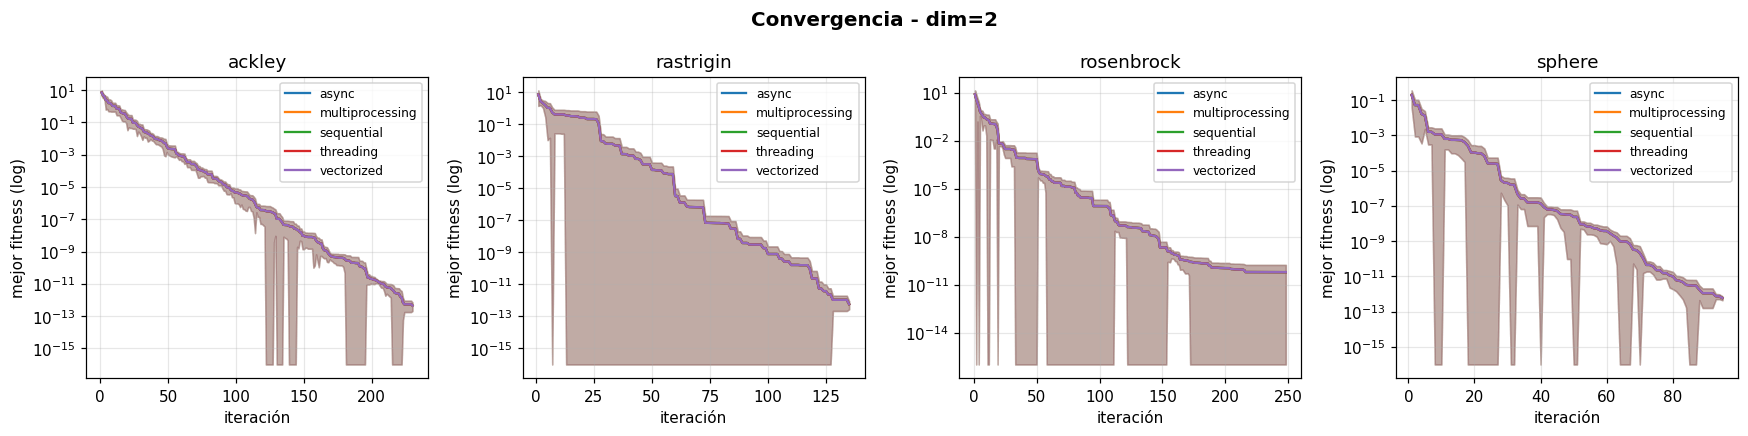

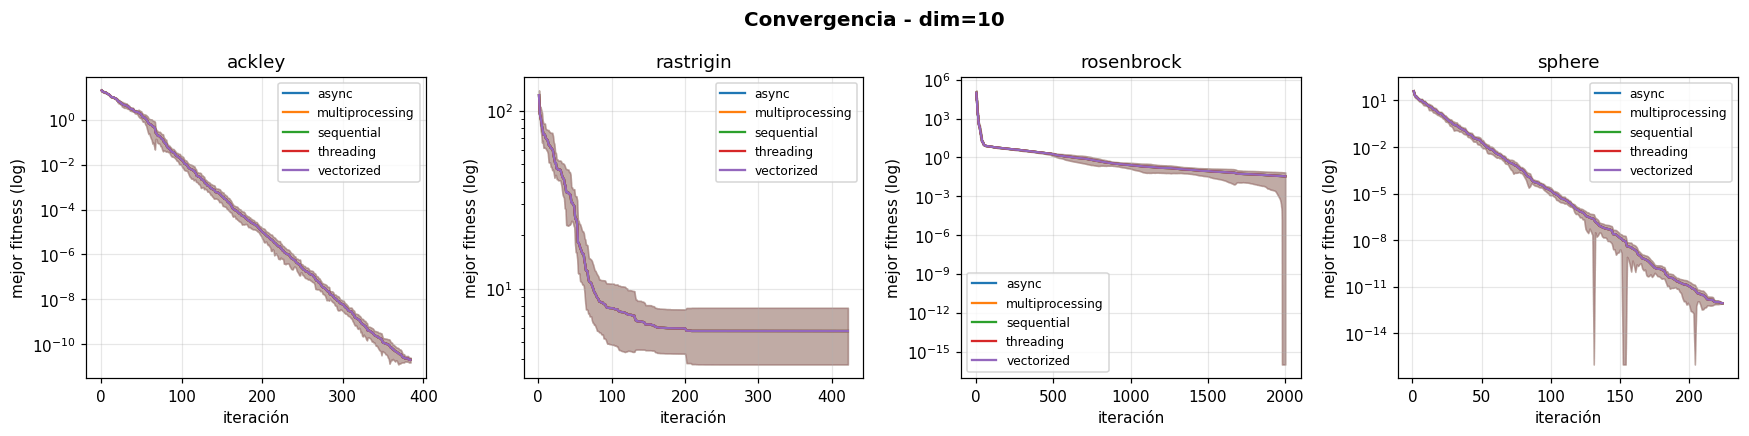

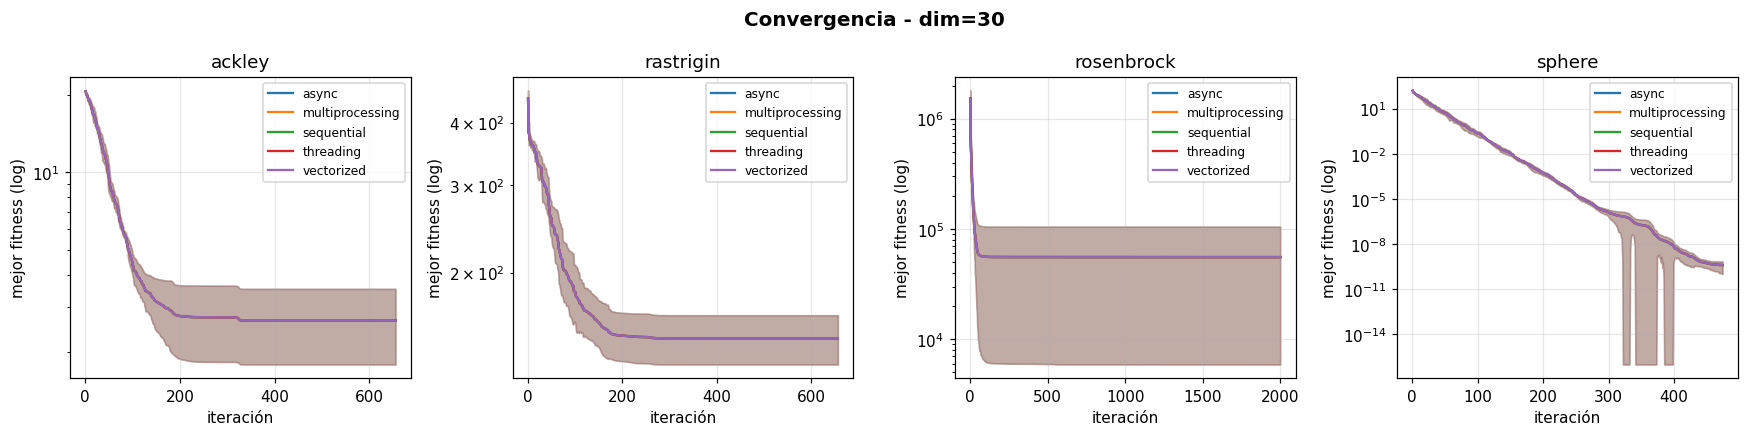

In [4]:
def pad_curves(curves):
    """Pad convergence curves to a common length by repeating the last value."""
    max_len = max(len(c) for c in curves)
    return np.array([c + c[-1:] * (max_len - len(c)) for c in curves])


objectives = sorted(df["objective"].dropna().unique())
dims = sorted(df["dim"].dropna().unique())
modes_iter = [m for m in sorted(df["mode"].dropna().unique()) if m != "pyswarm"]

for dim in dims:
    sub = df[(df["dim"] == dim) & (df["best_fitness_by_iter"].notna())]
    fig, axes = plt.subplots(1, len(objectives), figsize=(4 * len(objectives), 4))
    if len(objectives) == 1:
        axes = [axes]
    fig.suptitle(f"Convergencia - dim={dim}", fontsize=13, fontweight="bold")

    for ax, obj in zip(axes, objectives):
        ax.set_title(obj)
        ax.set_xlabel("iteración")
        ax.set_ylabel("mejor fitness (log)")
        ax.set_yscale("log")

        for mode in modes_iter:
            curves = [
                c for c in
                sub[(sub["objective"] == obj) & (sub["mode"] == mode)]["best_fitness_by_iter"]
                if c is not None
            ]
            if not curves:
                continue
            mat = pad_curves(curves)
            mean = mat.mean(axis=0)
            std = mat.std(axis=0)
            x = np.arange(1, len(mean) + 1)
            line, = ax.plot(x, mean, label=mode)
            ax.fill_between(
                x,
                np.maximum(mean - std, 1e-16),
                mean + std,
                alpha=0.15, color=line.get_color(),
            )
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

- La caída inicial es muy rápida (Sphere, Rosenbrock y Ackley pasan varias órdenes de magnitud en las primeras iteraciones).
- Rastrigin en d=30 se queda atascado en un valle local: la curva se aplana con un fitness lejos del óptimo. Es lo que se espera de una función multimodal cuando el tamaño del enjambre no es suficiente.
- Las cinco curvas por panel se superponen casi por completo, confirmando que el núcleo del PSO es el mismo en todas las variantes.

## 4. Distribucion por modo

Boxplots del gap al óptimo por modo, para cada combinación (objetivo, dimensión). Los ceros exactos se sustituyen por `1e-16` para que la escala logarítmica funcione.

Esto sirve sobre todo para comparar nuestro PSO contra `pyswarm`. Entre las variantes propias el boxplot debe ser prácticamente idéntico.

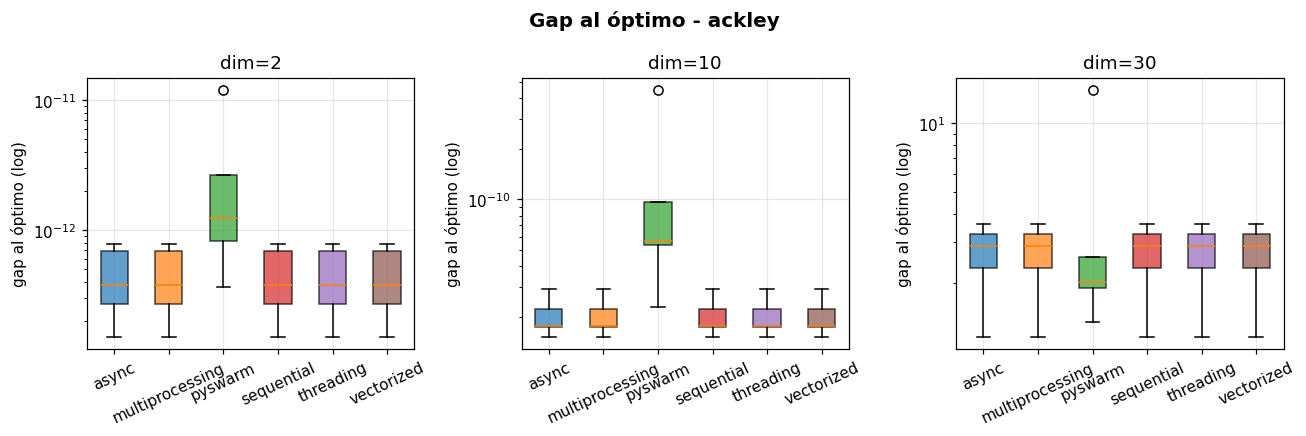

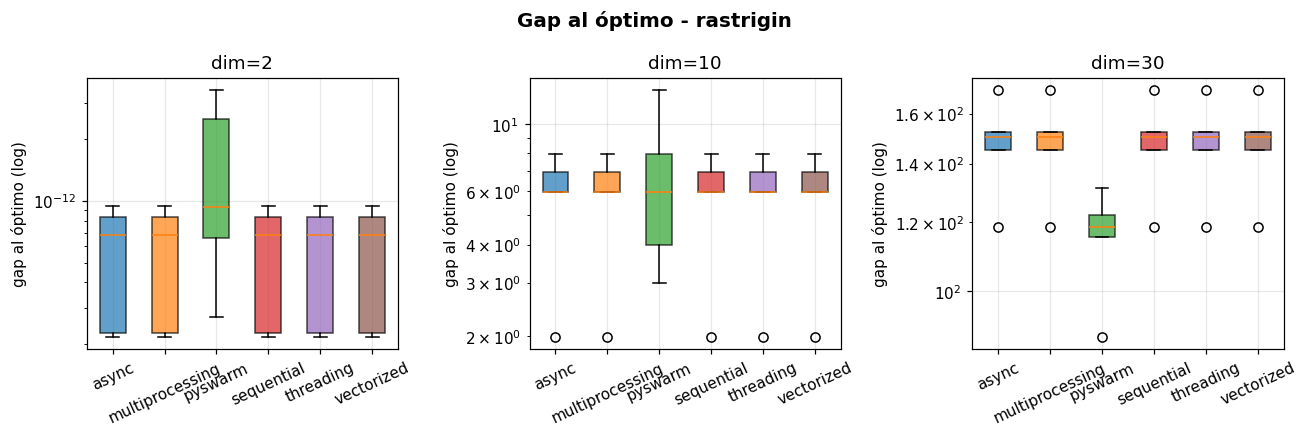

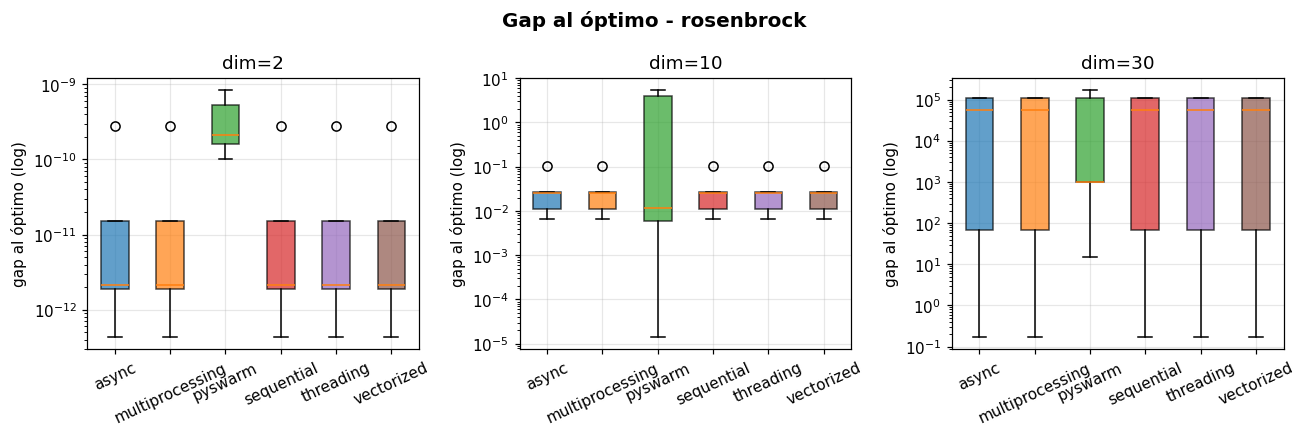

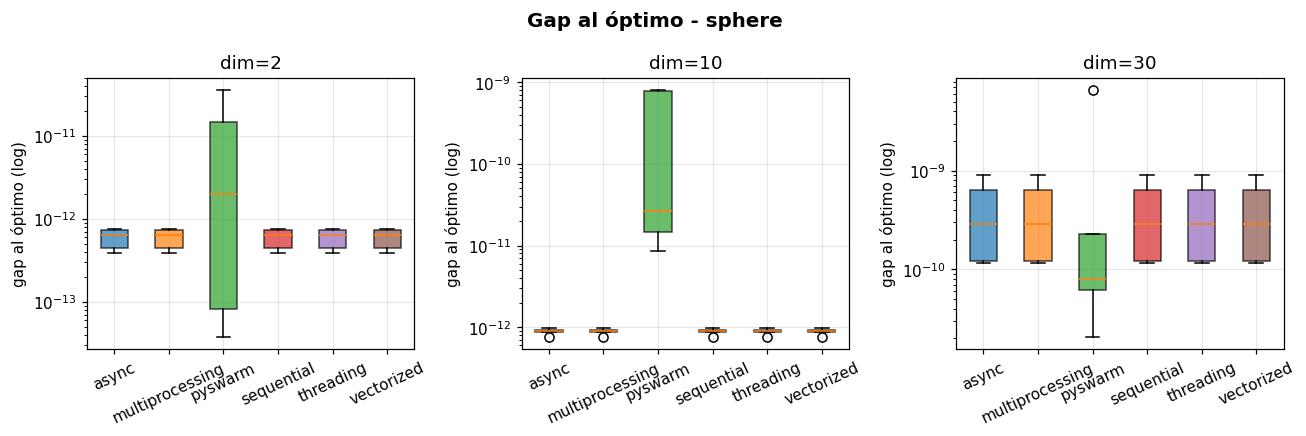

In [5]:
all_modes = sorted(df["mode"].dropna().unique())
colors = plt.cm.tab10.colors

for obj in objectives:
    fig, axes = plt.subplots(1, len(dims), figsize=(4 * len(dims), 4))
    if len(dims) == 1:
        axes = [axes]
    fig.suptitle(f"Gap al óptimo - {obj}", fontsize=13, fontweight="bold")

    for ax, dim in zip(axes, dims):
        ax.set_title(f"dim={dim}")
        ax.set_ylabel("gap al óptimo (log)")
        ax.set_yscale("log")

        data, labels = [], []
        for mode in all_modes:
            vals = df[
                (df["objective"] == obj) &
                (df["dim"] == dim) &
                (df["mode"] == mode)
            ]["gap_to_optimum"].dropna().values
            if len(vals) > 0:
                vals = np.where(vals == 0, 1e-16, vals)
                data.append(vals)
                labels.append(mode)

        if data:
            bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, notch=False)
            for patch, color in zip(bp["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.show()

- Para Sphere y Rosenbrock las cajas de nuestras 5 variantes están prácticamente solapadas; nuestro PSO compite con `pyswarm` en dimensión baja y a menudo lo mejora.
- En Rastrigin d=30 la dispersión es enorme: depende mucho de la seed (qué tan cerca de un atractor cae el enjambre inicial). Es el ejemplo típico de optimización multimodal difícil.
- Ackley se comporta de forma muy consistente: la caja es estrecha incluso en d=30.

## 5. Speedup vs sequential

Speedup = `time_sequential / time_mode`. Un valor > 1 significa más rápido que el secuencial, < 1 más lento. Excluimos `pyswarm` porque su tiempo no es directamente comparable debido a otros criterios de parada y otra implementación interna

- `threading` debería ser **más lento** que `sequential` por el coste del GIL y del pool de hilos.
- `multiprocessing` también probablemente más lento, dominado por el IPC y el pickling de las posiciones. Solo compensaría con funciones objetivo caras.
- `async` será claramente más lento porque introduce latencia simulada (5-20 ms por partícula).
- `vectorized` debería ser el **más rápido**: una sola llamada a NumPy procesa todas las partículas sin loops Python.

Speedup vs sequential  (>1 = más rápido, <1 = más lento)



,objective,dim,speedup_async,speedup_multiprocessing,speedup_sequential,speedup_threading,speedup_vectorized
0,ackley,2,0.016,0.018,1.0,0.074,8.745
1,ackley,10,0.016,0.027,1.0,0.083,7.027
2,ackley,30,0.021,0.044,1.0,0.114,5.626
3,rastrigin,2,0.011,0.010,1.0,0.087,8.903
4,rastrigin,10,0.012,0.020,1.0,0.079,5.220
5,rastrigin,30,0.013,0.025,1.0,0.086,4.123
6,rosenbrock,2,0.023,0.035,1.0,0.188,7.782
7,rosenbrock,10,0.018,0.065,1.0,0.134,7.502
8,rosenbrock,30,0.017,0.068,1.0,0.107,5.681
9,sphere,2,0.016,0.011,1.0,0.098,3.040


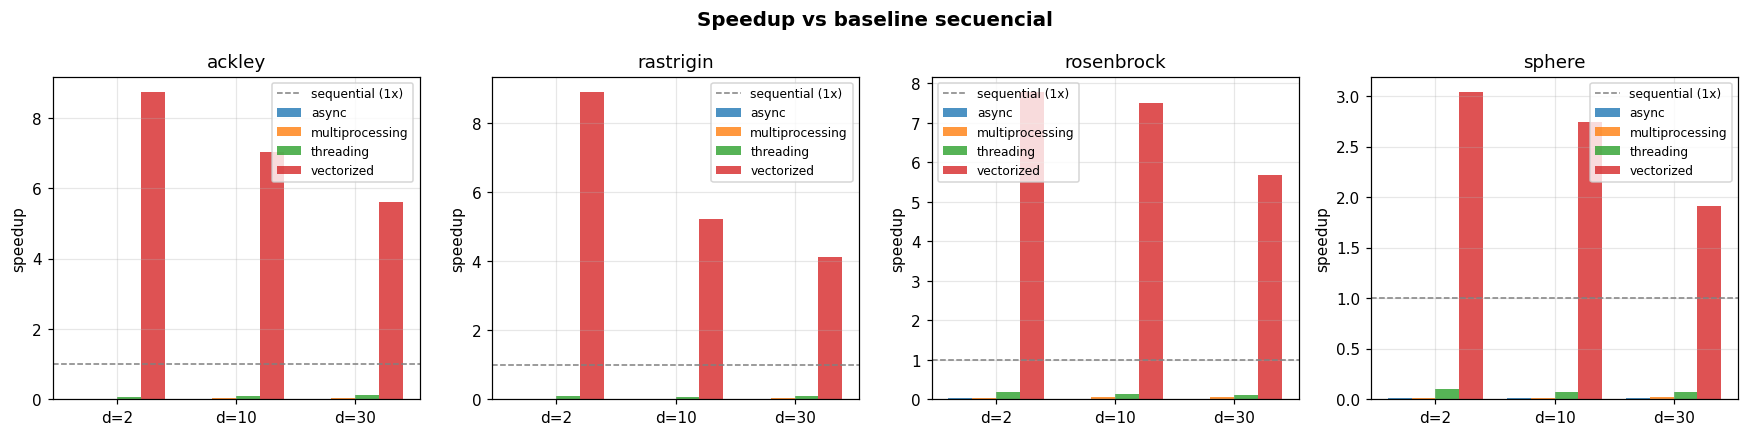

In [6]:
custom = df[df["mode"] != "pyswarm"].copy()

mean_times = (
    custom.groupby(["objective", "dim", "mode"])["total_time"]
    .mean()
    .reset_index()
    .rename(columns={"total_time": "mean_time"})
)

pivot_times = mean_times.pivot_table(
    index=["objective", "dim"], columns="mode", values="mean_time"
)

if "sequential" not in pivot_times.columns:
    print("No 'sequential' mode found - cannot compute speedup.")
else:
    # speedup = time_sequential / time_mode  ->  >1 means faster than sequential
    seq_times = pivot_times["sequential"]
    speedup_df = pd.DataFrame(
        {col: seq_times / pivot_times[col] for col in pivot_times.columns},
        index=pivot_times.index,
    )
    speedup_df.columns = [f"speedup_{c}" for c in speedup_df.columns]
    speedup_df = speedup_df.reset_index()

    print("Speedup vs sequential  (>1 = más rápido, <1 = más lento)\n")
    display(speedup_df.round(3))

    speedup_cols = [
        c for c in speedup_df.columns
        if c.startswith("speedup_") and c != "speedup_sequential"
    ]

    fig, axes = plt.subplots(
        1, len(objectives), figsize=(4 * len(objectives), 4), sharey=False
    )
    if len(objectives) == 1:
        axes = [axes]
    fig.suptitle("Speedup vs baseline secuencial", fontsize=13, fontweight="bold")

    for ax, obj in zip(axes, objectives):
        ax.set_title(obj)
        ax.set_ylabel("speedup")
        ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="sequential (1x)")

        sub = speedup_df[speedup_df["objective"] == obj]
        x = np.arange(len(sub))
        w = 0.8 / max(len(speedup_cols), 1)

        for k, col in enumerate(speedup_cols):
            mode_name = col.replace("speedup_", "")
            offset = (k - len(speedup_cols) / 2 + 0.5) * w
            ax.bar(
                x + offset, sub[col].values, width=w,
                label=mode_name, color=colors[k], alpha=0.8,
            )

        ax.set_xticks(x)
        ax.set_xticklabels([f"d={d}" for d in sub["dim"].values])
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

- **`threading`** sale claramente perdedor. El GIL serializa el bytecode Python y las funciones objetivo son tan baratas que el overhead del pool de hilos domina. Solo compensaría si la función objetivo pasara la mayor parte de su tiempo dentro de C/NumPy liberando el GIL, lo cual no es nuestro caso.
- **`multiprocessing`** también sale perdedor para estas funciones. El coste de serializar las posiciones, mandarlas a los workers y traer los resultados de vuelta supera el ahorro por paralelismo real. Compensaría si cada evaluación de fitness tardara, digamos, decenas de milisegundos.
- **`async`** es el peor de todos en términos de tiempo, pero por razones distintas: introducimos latencia simulada (5-20 ms por partícula) para demostrar el caso donde el fitness depende de I/O. El speedup que vemos es contra un mundo hipotético donde cada llamada esperaría secuencialmente. En términos absolutos es lento por la latencia añadida.
- **`vectorized`** es el ganador claro y por mucho. Una única llamada a NumPy procesa toda la matriz de posiciones sin pasar nunca por un loop de Python. Es la única estrategia que tiene sentido para benchmarks como estos.

Para funciones objetivo baratas, la vectorización es la opción correcta. Para funciones caras (CPU-bound de varios ms cada una) habría que volver a probar `multiprocessing`. `threading` solo gana cuando el GIL se libera (NumPy, BLAS, llamadas a C). `async` está reservado a casos con I/O real.

## 6. Conclusiones

- Las cinco variantes de evaluación dan exactamente el mismo resultado para la misma seed, lo cual valida que el núcleo del PSO es independiente de la estrategia de evaluación.
- Nuestra implementación compite bien con `pyswarm` en calidad de solución y, gracias a `vectorized`, también en tiempo.
- Los puntos débiles del PSO en estos benchmarks aparecen en Rastrigin d=30, donde la multimodalidad atrapa al enjambre en valles locales. Subir el tamaño del enjambre o las iteraciones podría ayudar, pero ese análisis queda fuera de este cuaderno.